In [1]:
# 시각화 라이브러리
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 처리
import pandas as pd
import numpy as np

# 펭귄 데이터 불러오기
df = sns.load_dataset("penguins")


# 상위 5개 출력
print(df.head())

# df.to_excel("펭귄.xlsx")

# species → 펭귄 종류 (목표 확인용)
# island → 서식 섬
# bill_length_mm → 부리 길이
# bill_depth_mm → 부리 깊이
# flipper_length_mm → 날개 길이
# body_mass_g → 몸무게
# sex → 성별

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [3]:
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [5]:
# 결측치 제거
# 수치형만 보기 위해 제거해 버림

df = df.dropna()

df.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 20.8 KB


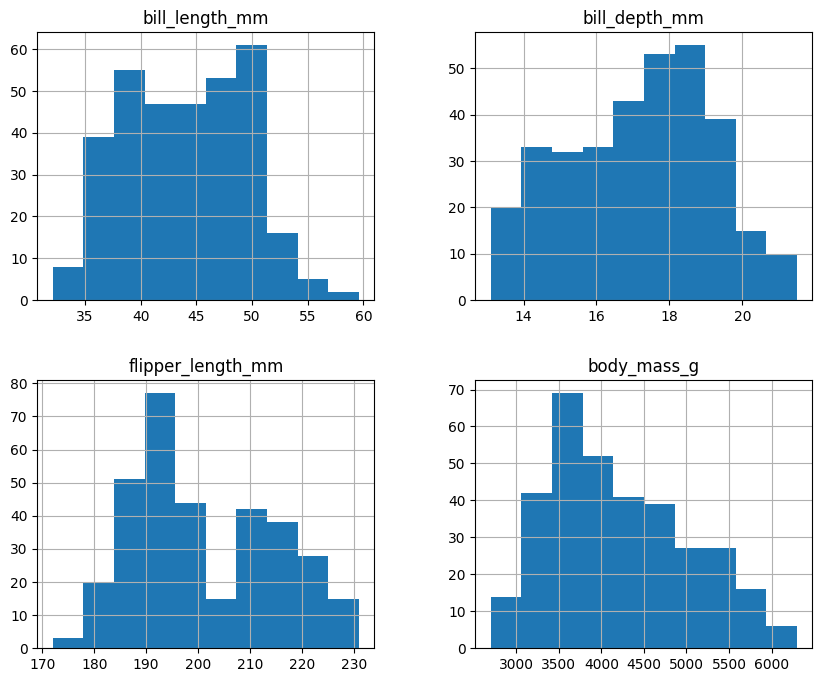

In [6]:
# 수치 컬럼만
num_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

# 히스토그램
df[num_cols].hist(
    figsize=(10,8)
)

plt.show()

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.228626           0.653096   
bill_depth_mm           -0.228626       1.000000          -0.577792   
flipper_length_mm        0.653096      -0.577792           1.000000   
body_mass_g              0.589451      -0.472016           0.872979   

                   body_mass_g  
bill_length_mm        0.589451  
bill_depth_mm        -0.472016  
flipper_length_mm     0.872979  
body_mass_g           1.000000  


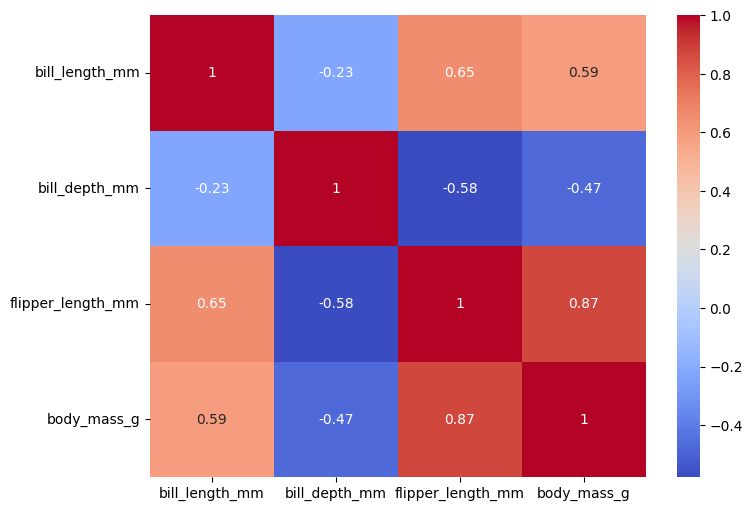

In [7]:
# 상관계수 계산
corr = df[num_cols].corr()

print(corr)
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

# 입력 데이터 선택
X = df[num_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[-0.89604189  0.7807321  -1.42675157 -0.56847478]
 [-0.82278787  0.11958397 -1.06947358 -0.50628618]
 [-0.67627982  0.42472926 -0.42637319 -1.1903608 ]
 [-1.33556603  1.0858774  -0.56928439 -0.94160639]
 [-0.85941488  1.74702554 -0.78365118 -0.69285199]]


In [9]:
# PCA 수행
from sklearn.decomposition import PCA
# 2차원 축소
pca = PCA(n_components=2)
# PCA 적용
X_pca = pca.fit_transform(X_scaled)
print(X_pca[:5])

[[-1.85359302  0.03206938]
 [-1.31625406 -0.44352677]
 [-1.37660509 -0.16123048]
 [-1.88528838 -0.01235124]
 [-1.91998074  0.81759813]]


[0.68633893 0.19452929]


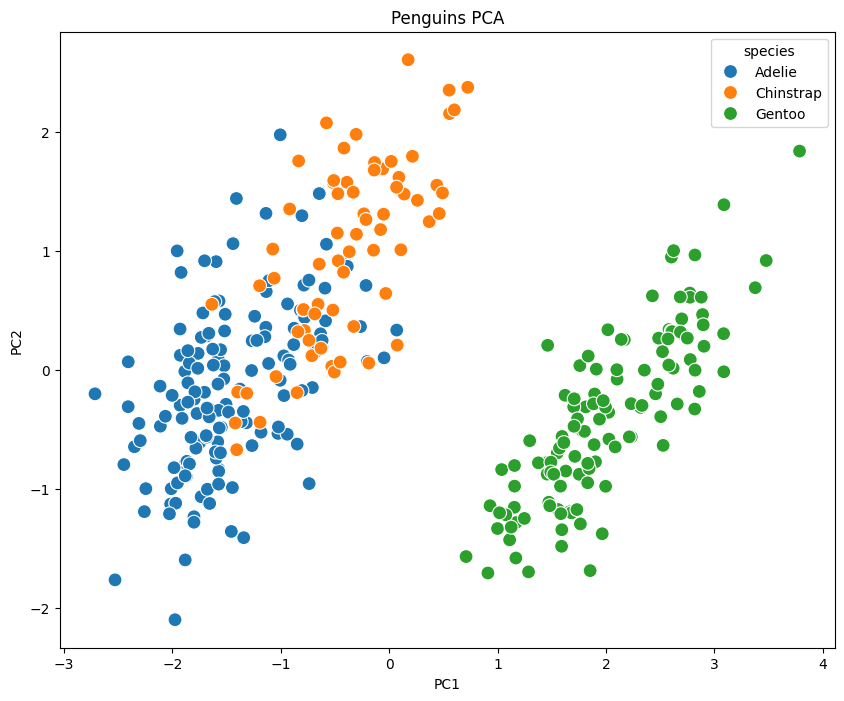

In [11]:
print(pca.explained_variance_ratio_)
# 설명력은 89%

# PCA 결과 시각화

# 데이터프레임 생성
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)


# 종 정보 추가
pca_df["species"] = df["species"].values


# 그래프
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species",
    s=100
)

plt.title("Penguins PCA")

plt.show()


In [ ]:
print(pca.components_)

loading = pd.DataFrame(
    pca.components_,
    columns=num_cols,
    index=["PC1","PC2"]
)

print(loading)

# pc1 => 몸무게 + 날개길이 = 덩치
# pc2 => 부리

[[ 0.45375317 -0.39904723  0.576825    0.54967471]
 [ 0.6001949   0.79616951  0.00578817  0.07646366]]
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
PC1        0.453753      -0.399047           0.576825     0.549675
PC2        0.600195       0.796170           0.005788     0.076464
